# Error analysis — physics solver results

Reads a `results/*.csv` (or its JSON sibling), categorises every wrong row into a fail mode, and lets you eyeball examples per mode + per domain.

Edit `RESULTS_CSV` below to switch versions. The same notebook works for v01, v02, v03, ...

In [1]:
import os, sys
# When run from inside the repo, make the package importable.
if 'app' not in os.listdir('.'):
    # Walk up until we find it (handles being run from .ipynb's own dir).
    here = os.path.abspath('.')
    while here != os.path.dirname(here) and not os.path.isdir(os.path.join(here, 'app')):
        here = os.path.dirname(here)
    os.chdir(here)
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())
print('cwd:', os.getcwd())

RESULTS_CSV = 'app/physics_solution/results/v02_fewshot.csv'  # change me
REPORT_OUT  = 'docs/eda/v02_error_report.md'                  # markdown to write
N_EXAMPLES  = 5

cwd: d:\Git\Exact_2026_Laplace-s_Red_Devils


In [2]:
from app.physics_solution.eda.error_analysis import analyse
report = analyse(RESULTS_CSV, n_examples_per_mode=N_EXAMPLES)
print(f'Total: {report.total}, correct: {report.correct} ({report.accuracy:.3f}), wrong: {report.wrong}')

Total: 973, correct: 453 (0.466), wrong: 520


## 1. Fail-mode breakdown


In [3]:
import pandas as pd
wrong = max(report.wrong, 1)
fm = (
    pd.Series(report.failmode_counts, name='count')
      .sort_values(ascending=False)
      .to_frame()
)
fm['% of wrong'] = (fm['count'] / wrong * 100).round(1)
fm

,count,% of wrong
numeric_far,170,32.7
magnitude_wrong,169,32.5
off_by_power10,165,31.7
format_no_final,10,1.9
unit_mismatch,4,0.8
format_bad_number,2,0.4


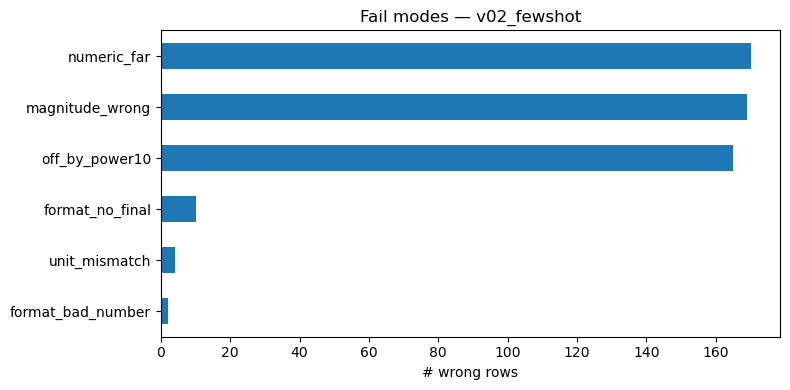

In [4]:
# Bar chart of fail modes
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 4))
fm['count'].plot.barh(ax=ax)
ax.invert_yaxis()
ax.set_xlabel('# wrong rows')
ax.set_title(f'Fail modes — {report.version}')
plt.tight_layout()
plt.show()

## 2. Per-domain accuracy


In [5]:
report.domain_breakdown

,domain,n,correct,accuracy
0,CH,289,138,0.478
3,LD,201,50,0.249
5,TD,167,37,0.222
4,NL,160,119,0.744
1,DDT,78,63,0.808
2,DT,39,11,0.282
6,THCB,39,35,0.897


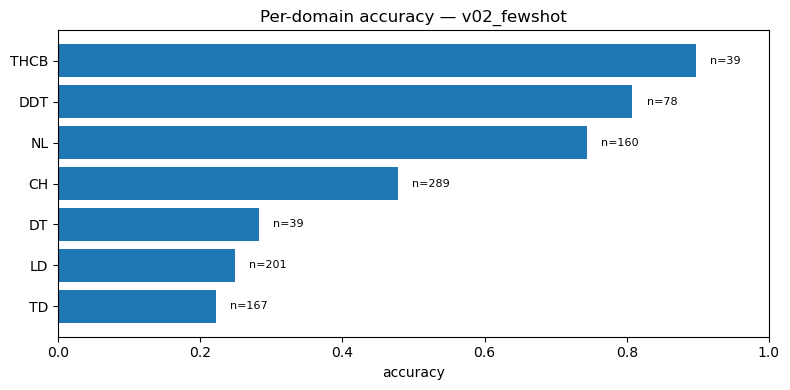

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
d = report.domain_breakdown.sort_values('accuracy')
ax.barh(d['domain'], d['accuracy'])
ax.set_xlim(0, 1)
ax.set_xlabel('accuracy')
ax.set_title(f'Per-domain accuracy — {report.version}')
for i, (acc, n) in enumerate(zip(d['accuracy'], d['n'])):
    ax.text(acc + 0.01, i, f'  n={n}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## 3. Fail mode × domain


In [7]:
report.domain_x_failmode

domain,CH,DDT,DT,LD,NL,TD,THCB
fail_mode,,,,,,,
format_bad_number,2,0,0,0,0,0,0
format_no_final,8,0,0,1,0,1,0
magnitude_wrong,95,3,12,31,12,14,2
numeric_far,31,2,15,108,6,8,0
off_by_power10,15,10,1,11,23,105,0
unit_mismatch,0,0,0,0,0,2,2


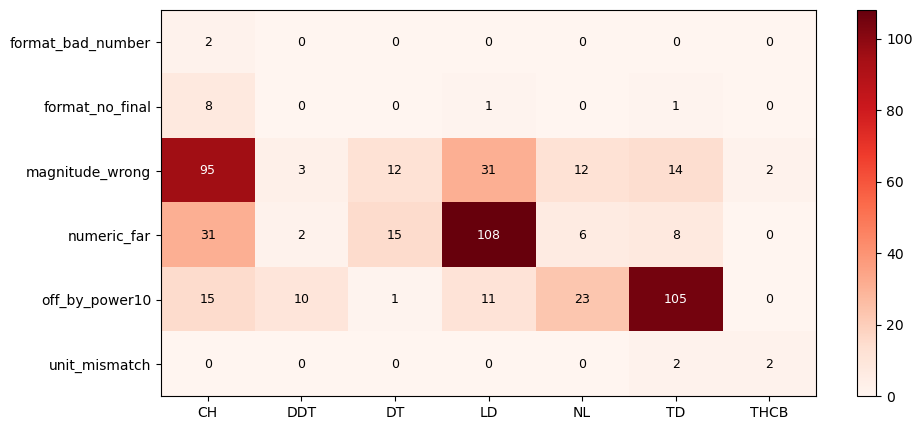

In [8]:
# Heatmap — quickly see which domains drive which fail modes.
if not report.domain_x_failmode.empty:
    fig, ax = plt.subplots(figsize=(10, 0.4 * len(report.domain_x_failmode) + 2))
    import numpy as np
    m = report.domain_x_failmode.values
    im = ax.imshow(m, cmap='Reds', aspect='auto')
    ax.set_xticks(range(report.domain_x_failmode.shape[1]))
    ax.set_xticklabels(report.domain_x_failmode.columns)
    ax.set_yticks(range(report.domain_x_failmode.shape[0]))
    ax.set_yticklabels(report.domain_x_failmode.index)
    for (i, j), val in np.ndenumerate(m):
        ax.text(j, i, int(val), ha='center', va='center',
                color='white' if val > m.max() * 0.5 else 'black', fontsize=9)
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

## 4. Eyeball examples per fail mode

These should make the categorisation tangible — if a fail mode looks miscategorised, fix the heuristic in `error_analysis.py`.

In [9]:
for mode, examples in report.examples_per_mode.items():
    print(f'=== {mode} ({report.failmode_counts.get(mode, 0)}) ===')
    for ex in examples:
        print(f"  {ex['id']:>10}  gold={ex['gold_answer']!s:>10}  pred={ex['pred_numeric']!s:>12}  "
              f"unit_gold={ex['gold_unit']!s:>6}  unit_pred={ex['pred_unit']!s:>6}")
        q = (ex.get('question') or '')[:180]
        print(f"             Q: {q}")
    print()

=== format_bad_number (2) ===
       CH259  gold=     180.0  pred=         nan  unit_gold=     V  unit_pred=     V
             Q: A circuit has XL = 35 Ω, XC = 140 Ω, and a source voltage U = 180 V. If the frequency is doubled, what is the voltage across R?
       CH256  gold=     200.0  pred=         nan  unit_gold=     V  unit_pred=   nan
             Q: An RLC circuit has an inductive reactance XL = 18 Ω, a capacitive reactance XC = 72 Ω, and the total voltage U = 200 V. When the frequency is doubled, what is the RMS voltage acros

=== format_no_final (10) ===
       CH228  gold=      50.0  pred=         0.0  unit_gold=     Ω  unit_pred=   nan
             Q: The circuit AB consists of R1 = 50 Ω and a segment MB (containing R2 and an inductor L), satisfying the condition LCω² = 1. The voltage uAM and uMB are in quadrature (90 degrees ou
       CH219  gold=      67.5  pred=        90.0  unit_gold=     W  unit_pred=   nan
             Q: Circuit AB comprises two segments connected in

## 5. Drill into a single fail mode

Set `FOCUS_MODE` below to inspect more rows from one category — useful when designing v03/v04 fixes.

In [10]:
FOCUS_MODE = 'magnitude_wrong'  # or 'off_by_power10' / 'unit_mismatch' / ...
subset = report.wrong_df[report.wrong_df['fail_mode'] == FOCUS_MODE]
print(f'Rows: {len(subset)}')
subset[['id', 'domain', 'gold_answer', 'pred_numeric', 'gold_unit', 'pred_unit']].head(20)

Rows: 169


,id,domain,gold_answer,pred_numeric,gold_unit,pred_unit
0,CH085,CH,5.070,25.33,μF,μF
1,CH245,CH,64.000,16.00,W,W
2,CH109,CH,46.190,12.57,Ω,Ω
3,CH261,CH,130.000,104.50,V,V
4,CH144,CH,63.300,110.00,V,V
11,CH040,CH,56.270,79.79,Hz,Hz
15,CH194,CH,1.414,2.00,-,1
16,CH201,CH,3.000,9.00,-,1
17,CH356,CH,87.940,55.15,µF,μF
20,CH174,CH,337.500,675.00,W,W


In [11]:
# Full completion for one focus-mode example.
if not subset.empty:
    row = subset.iloc[0]
    print('ID:', row['id'])
    print('Question:', row['question'])
    print('Gold:', row['gold_answer'], row['gold_unit'])
    print('Pred:', row['pred_numeric'], row['pred_unit'])
    print()
    print('--- completion ---')
    print(str(row['completion'])[:2000])

ID: CH085
Question: A circuit needs to resonate at 1000 Hz. Given an inductor L=0.005 H, what capacitance C is needed?
Gold: 5.07 μF
Pred: 25.33 μF

--- completion ---
Step 1: Rearrange the resonance frequency formula $f = \frac{1}{2\pi\sqrt{LC}}$ to solve for capacitance $C$.
Step 2: Substitute the target frequency $f = 1000$ Hz and inductance $L = 0.005$ H into the rearranged equation.
Step 3: Calculate the value of $C$ by dividing 1 by $(2\pi \times 1000)^2$ and then multiplying by $L$.
Step 4: Convert the resulting capacitance from farads to microfarads for the final answer.

FINAL ANSWER: 25.33
UNIT: μF



## 6. Write the report


In [12]:
out = report.write(REPORT_OUT)
print(f'Wrote {out}')

Wrote docs\eda\v02_error_report.md
